# deepSSF — train, validate, simulate

End-to-end example using the bundled buffalo GPS dataset and two static raster
covariates (NDVI and slope).  The notebook calls the package throughout;
training runs for just 3 epochs so it completes quickly on CPU.

**Sections**
1. Import data
2. Prepare data
3. Train model
4. Validate against withheld data
5. Simulate a trajectory

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

import deepssf
from deepssf import (
    ConvJointModel,
    EarlyStopping,
    ModelParams,
    create_gif,
    fit,
    get_device,
    load_environmental_layers,
    make_dataloaders,
    make_optimisers,
    negativeLogLikeLoss,
    filter_steps_by_window,
    prepare_movement_df,
    simulate_trajectory,
    validate_next_step_probs,
)

import pandas as pd

print(f"deepssf {deepssf.__version__}")
print(f"torch {torch.__version__}")

deepssf 0.1.0
torch 2.12.0


In [2]:
# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = get_device()
print(f"Device: {DEVICE}")

Device: mps


## 1  Import data

In [3]:
DATA_DIR = Path("../src/deepssf/datasets/data")
CSV_PATH = DATA_DIR / "buffalo_djelk_id2005.csv"
LAYER_PATHS = {
    "ndvi":  str(DATA_DIR / "ndvi_2005.tif"),
    "slope": str(DATA_DIR / "slope_2005.tif"),
}
OUTPUT_DIR  = Path("outputs")
SNAPSHOT_DIR = OUTPUT_DIR / "training_snapshots"
OUTPUT_DIR.mkdir(exist_ok=True)

In [4]:
raw_df = pd.read_csv(CSV_PATH)
print(f"Raw GPS fixes : {len(raw_df):,}")
print(f"Individuals   : {raw_df['id'].nunique()}")
raw_df.head()

Raw GPS fixes : 10,297
Individuals   : 1


,id,time,x,y
0,2005,2019-01-01T01:01:14Z,34640.715922,-1.437396e+06
1,2005,2019-01-01T11:00:59Z,34659.722605,-1.437209e+06
2,2005,2019-01-01T12:01:15Z,34656.290501,-1.437223e+06
3,2005,2019-01-01T13:01:28Z,34669.029522,-1.437219e+06
4,2005,2019-01-01T14:01:12Z,34662.964751,-1.437221e+06


In [5]:
env_layers, raster_transform = load_environmental_layers(LAYER_PATHS)
print("Layers loaded:", list(env_layers.keys()))
for name, arr in env_layers.items():
    print(f"  {name}: shape={arr.shape}, min={arr.min():.3f}, max={arr.max():.3f}")

Layer 'ndvi': min=-0.06614641100168228, max=0.731696367263794 → scaled to [0, 1]
Layer 'slope': min=0.00013558653881773353, max=12.298083305358887 → scaled to [0, 1]
Layers loaded: ['ndvi', 'slope']
  ndvi: shape=(758, 1175), min=0.000, max=1.090
  slope: shape=(758, 1175), min=0.000, max=1.000


## 2  Prepare data

In [6]:
step_df = prepare_movement_df(raw_df)
print(f"Movement steps : {len(step_df):,}  ({len(raw_df) - len(step_df)} dropped — last fix per individual)")
step_df.head()

Movement steps : 10,296  (1 dropped — last fix per individual)


,id,t1_,x1_,y1_,x2_,y2_,dx,dy,bearing,bearing_tm1,dt_hour,hour_t1,yday_t1,hour_t1_sin1,hour_t1_cos1,yday_t1_sin1,yday_t1_cos1
0,2005,2018-07-25T00:04:02Z,41941.331695,-1.435875e+06,41969.310875,-1.435671e+06,27.979180,204.064135,1.434536,0.000000,1.005833,0.066667,206.0,0.017452,0.999848,-0.391358,-0.920239
1,2005,2018-07-25T01:04:23Z,41969.310875,-1.435671e+06,41921.521939,-1.435654e+06,-47.788936,16.857110,2.802478,1.434536,1.004444,1.066667,206.0,0.275637,0.961262,-0.391358,-0.920239
2,2005,2018-07-25T02:04:39Z,41921.521939,-1.435654e+06,41779.439594,-1.435601e+06,-142.082345,53.568427,2.781049,2.802478,0.993889,2.066667,206.0,0.515038,0.857167,-0.391358,-0.920239
3,2005,2018-07-25T03:04:17Z,41779.439594,-1.435601e+06,41841.203272,-1.435635e+06,61.763677,-34.322938,-0.507220,2.781049,1.006111,3.066667,206.0,0.719340,0.694658,-0.391358,-0.920239
4,2005,2018-07-25T04:04:39Z,41841.203272,-1.435635e+06,41655.463332,-1.435604e+06,-185.739939,31.003534,2.976198,-0.507220,0.996667,4.066667,206.0,0.874620,0.484810,-0.391358,-0.920239


In [7]:
# Model configuration
# 4 scalar covariates broadcast into spatial maps (no dt_hour so simulate() matches)
SCALAR_COLS = ["hour_t1_sin1", "hour_t1_cos1", "yday_t1_sin1", "yday_t1_cos1"]
WINDOW_SIZE = 25    # small for speed; 101 is typical for production
PIXEL_SIZE  = 25    # raster resolution in metres (CRS units)
BATCH_SIZE  = 32

# Calculate the flat size of the movement CNN output after 3× conv+maxpool
OUTPUT_CHANNELS = 4
dim = WINDOW_SIZE
for _ in range(3):
    dim = math.floor((dim + 2 * 1 - 3) / 1 + 1)  # conv: pad=1 keeps dim
    dim = math.floor((dim - 2) / 2 + 1)           # maxpool k=2, s=2
DENSE_DIM = OUTPUT_CHANNELS * dim * dim
print(f"After 3× conv+maxpool: dim={dim}  →  dense_dim_in_all={DENSE_DIM}")

# Drop steps whose displacement exceeds the window; would cause an index error in the loss
step_df = filter_steps_by_window(step_df, window_size=WINDOW_SIZE, pixel_size=PIXEL_SIZE)
print(f"Steps after window filter: {len(step_df):,}")


After 3× conv+maxpool: dim=3  →  dense_dim_in_all=36
Steps after window filter: 7,927


In [8]:
dl_train, dl_val, dl_test = make_dataloaders(
    layer_paths=LAYER_PATHS,
    window_size=WINDOW_SIZE,
    batch_size=BATCH_SIZE,
    train_split=0.8,
    val_split=0.1,
    scalar_cols=SCALAR_COLS,
    df=step_df,
)
print(f"Train batches : {len(dl_train)}")
print(f"Val   batches : {len(dl_val)}")
print(f"Test  batches : {len(dl_test)}")

Layer 'ndvi': min=-0.06614641100168228, max=0.731696367263794 → scaled to [0, 1]
Layer 'slope': min=0.00013558653881773353, max=12.298083305358887 → scaled to [0, 1]


Train batches : 199
Val   batches : 25
Test  batches : 25


/Users/scottforrest/Library/Mobile Documents/com~apple~CloudDocs/github_repos/deepSSF_package/src/deepssf/data.py:358: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  self.scalar_to_grid_data = torch.from_numpy(


In [9]:
# Inspect one batch
x1, x2, x3, (px2, py2), _ = next(iter(dl_train))
print(f"Spatial   x1 : {x1.shape}   (batch × channels × H × W)")
print(f"Scalars   x2 : {x2.shape}")
print(f"Bearing   x3 : {x3.shape}")
print(f"Next-step px2: {px2[:4].tolist()}  py2: {py2[:4].tolist()}")

Spatial   x1 : torch.Size([32, 2, 25, 25])   (batch × channels × H × W)
Scalars   x2 : torch.Size([32, 4])
Bearing   x3 : torch.Size([32, 1])
Next-step px2: [11, 9, 12, 12]  py2: [12, 16, 12, 12]


## 3  Train model

In [10]:
params = ModelParams({
    "batch_size":                BATCH_SIZE,
    "image_dim":                 WINDOW_SIZE,
    "pixel_size":                PIXEL_SIZE,
    "dim_in_nonspatial_to_grid": len(SCALAR_COLS),
    "dense_dim_in_nonspatial":   len(SCALAR_COLS),
    "dense_dim_hidden":          64,
    "dense_dim_in_all":          DENSE_DIM,
    "input_channels":            2 + len(SCALAR_COLS),  # 2 spatial + 4 scalar-to-grid
    "output_channels":           OUTPUT_CHANNELS,
    "kernel_size":               3,
    "stride":                    1,
    "kernel_size_mp":            2,
    "stride_mp":                 2,
    "padding":                   1,
    "num_movement_params":       12,
    "dropout":                   0.0,
    "device":                    DEVICE,
})

model = ConvJointModel(params).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters : {n_params:,}")

Model parameters : 8,377


In [11]:
loss_fn     = negativeLogLikeLoss(reduction="mean")
optimisers, schedulers = make_optimisers(
    model, lr_habitat=1e-4, lr_movement=1e-5, scheduler_patience=2
)
early_stop  = EarlyStopping(
    patience=5, verbose=True, path=str(OUTPUT_DIR / "best_model.pt")
)

In [12]:
history = fit(
    model, dl_train, dl_val, loss_fn, optimisers, schedulers,
    n_epochs=3,
    early_stopping=early_stop,
    snapshot_dir=str(SNAPSHOT_DIR),
    snapshot_item=0,
)


Epoch 1/3
loss:        5.311125  [   32/ 6342]


loss:        4.477867  [  352/ 6342]
loss:        5.081835  [  672/ 6342]


loss:        5.583485  [  992/ 6342]
loss:        5.200701  [ 1312/ 6342]


loss:        4.755949  [ 1632/ 6342]
loss:        5.031434  [ 1952/ 6342]


loss:        4.946120  [ 2272/ 6342]
loss:        4.921370  [ 2592/ 6342]


...

loss:        5.042800  [ 4512/ 6342]
loss:        4.884730  [ 4832/ 6342]


loss:        5.008419  [ 5152/ 6342]
loss:        4.498147  [ 5472/ 6342]


loss:        4.934030  [ 5792/ 6342]
loss:        4.874654  [ 6112/ 6342]



Avg training loss:        5.019002
Val loss: 4.999141  (hab: 6.338997, mov: 5.020466)


Validation loss decreased (5.035266 → 4.999141). Saving model…


In [13]:
gif_path = str(OUTPUT_DIR / "training_progress.gif")
create_gif(str(SNAPSHOT_DIR), gif_path, fps=1)
print(f"Training GIF → {gif_path}")

Animation saved: outputs/training_progress.gif
Training GIF → outputs/training_progress.gif


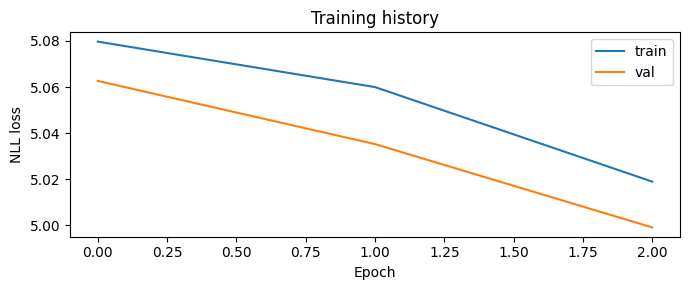

In [14]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(history["train_losses"], label="train")
ax.plot(history["val_losses"],   label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("NLL loss")
ax.legend()
ax.set_title("Training history")
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "loss_history.png"), dpi=100)
plt.show()

## 4  Validate against withheld test data

In [15]:
# Load the best checkpoint saved during training
model.load_state_dict(
    torch.load(str(OUTPUT_DIR / "best_model.pt"), map_location=DEVICE)
)
model.eval()
print("Best checkpoint loaded.")

Best checkpoint loaded.


In [16]:
# Wrap the static rasters as a landscape-loader callable.
# Month index is ignored here because we have static (non-S2) layers.
ndvi_t  = torch.from_numpy(env_layers["ndvi"].astype(np.float32))
slope_t = torch.from_numpy(env_layers["slope"].astype(np.float32))

def get_landscape(_month_index):
    return [ndvi_t, slope_t]

In [17]:
# Use the last 10 % of steps as the test set (matches the DataLoader split)
n_test      = int(len(step_df) * 0.1)
test_sample = step_df.iloc[-n_test:].reset_index(drop=True)
print(f"Validating on {len(test_sample):,} steps")

val_results = validate_next_step_probs(
    model,
    test_sample,
    get_landscape=get_landscape,
    transform=raster_transform,
    window_size=WINDOW_SIZE,
    scalar_cols=tuple(SCALAR_COLS),
    yday_col="yday_t1",
    bearing_col="bearing_tm1",
    month_index_fn=lambda _yday: 0,   # static layers — month doesn't matter
)
print(val_results[["habitat_prob", "move_prob", "next_step_prob"]].describe())

Validating on 792 steps


       habitat_prob   move_prob  next_step_prob
count    791.000000  791.000000      791.000000
mean       0.001824    0.014967        0.015707
std        0.000174    0.021296        0.022286
min        0.000000    0.000000        0.000000
25%        0.001796    0.002862        0.003045
50%        0.001856    0.007042        0.007302
75%        0.001900    0.018166        0.018943
max        0.002017    0.111349        0.117017


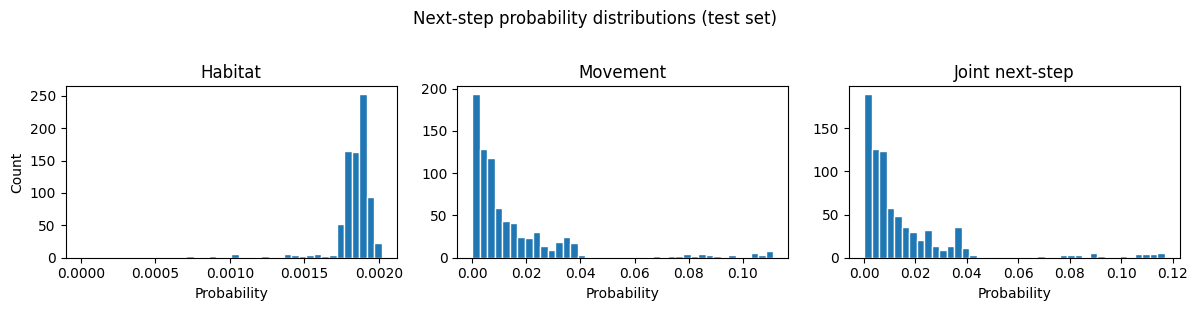

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, col, title in zip(
    axes,
    ["habitat_prob", "move_prob", "next_step_prob"],
    ["Habitat", "Movement", "Joint next-step"],
):
    data = val_results[col].dropna()
    ax.hist(data, bins=40, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Probability")
axes[0].set_ylabel("Count")
plt.suptitle("Next-step probability distributions (test set)", y=1.02)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "validation_probs.png"), dpi=100)
plt.show()

## 5  Simulate a trajectory

In [19]:
start_x = float(step_df["x1_"].median())
start_y = float(step_df["y1_"].median())
print(f"Starting location: ({start_x:.0f}, {start_y:.0f})")

sim_df = simulate_trajectory(
    model,
    get_landscape=get_landscape,
    transform=raster_transform,
    start_x=start_x,
    start_y=start_y,
    n_steps=1000,
    starting_yday=test_sample["yday_t1"].iloc[0],
    starting_hour=test_sample["hour_t1"].iloc[0],
    window_size=WINDOW_SIZE,
    month_index_fn=lambda _yday: 0,   # static layers
)
print(f"Simulated {len(sim_df)} steps")
sim_df.head()

Starting location: (36005, -1436897)


Simulated 1000 steps


,x,y,hour,yday,month_index,hab_log_prob,move_log_prob,step_log_prob
0,36230.272779,-1.436860e+06,15.916667,254.0,0,"[[-7.231035, -7.0174417, -6.8540783, -6.813139...","[[-8.993184, -8.883437, -8.771426, -8.657308, ...","[[-16.22422, -15.900879, -15.6255045, -15.4704..."
1,36397.764883,-1.436733e+06,16.916667,255.0,0,"[[-7.1946964, -6.993234, -6.844883, -6.807318,...","[[-8.867266, -8.7529125, -8.636148, -8.517185,...","[[-16.061962, -15.746147, -15.481031, -15.3245..."
2,36458.724292,-1.436466e+06,17.916667,256.0,0,"[[-7.169832, -6.974756, -6.8327208, -6.7913995...","[[-8.392048, -8.269302, -8.14439, -8.017746, -...","[[-15.56188, -15.244059, -14.977111, -14.80914..."
3,36589.072755,-1.436300e+06,18.916667,257.0,0,"[[-7.129837, -6.933236, -6.7892795, -6.7384496...","[[-7.6599827, -7.542865, -7.425521, -7.3087893...","[[-14.78982, -14.476101, -14.2148, -14.047239,..."
4,36592.806893,-1.436247e+06,19.916667,258.0,0,"[[-7.124019, -6.927795, -6.7872458, -6.7415056...","[[-8.115072, -7.992035, -7.867346, -7.74158, -...","[[-15.239092, -14.91983, -14.654592, -14.48308..."


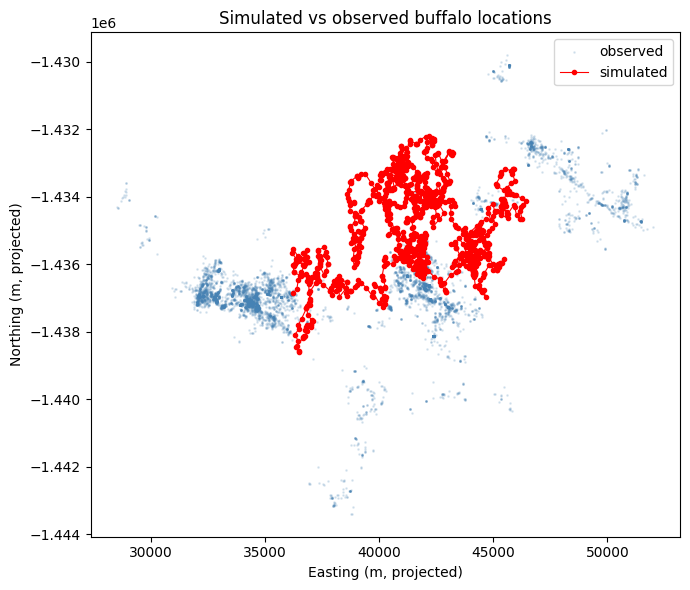

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    step_df["x1_"], step_df["y1_"],
    s=1, alpha=0.15, color="steelblue", label="observed",
)
ax.plot(
    sim_df["x"], sim_df["y"],
    "r-o", markersize=3, linewidth=0.8, label="simulated",
)
ax.set_xlabel("Easting (m, projected)")
ax.set_ylabel("Northing (m, projected)")
ax.legend()
ax.set_title("Simulated vs observed buffalo locations")
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "simulated_trajectory.png"), dpi=100)
plt.show()